Cài đặt thư viện

In [ ]:
import sys
# Cài đặt bộ PyTorch tương thích với torchtext và thư viện datasets
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2 --index-url https://download.pytorch.org/whl/cu121
!pip install datasets pandas numpy
!pip install "numpy<2"


Import và Thiết lập cấu hình (Hyperparameters)

In [2]:
import torch
import torch.nn as nn
import re
import time
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator, GloVe

# Cố định seed để kết quả có thể tái lập
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Thiết lập các siêu tham số cho mô hình
CONFIG = {
    "max_len": 128,
    "batch_size": 128,
    "embed_dim": 100,        # Bắt buộc là 100 để khớp với vector GloVe 6B-100d
    "hidden_dim": 256,
    "num_classes": 14,
    "epochs": 20,
    "lr": 2e-4
}
print(f"Thư viện đã sẵn sàng. Đang sử dụng thiết bị: {device}")

Thư viện đã sẵn sàng. Đang sử dụng thiết bị: cuda


Tải dữ liệu DBpedia-14 và Tiền xử lý (Làm sạch văn bản)

In [3]:
print("1. Đang tải DBpedia-14 từ Hugging Face Hub (Có thể mất 1-2 phút)...")
raw_datasets = load_dataset("dbpedia_14")

# Tách tập test thành test (90%) và validation (10%)
split_test = raw_datasets["test"].train_test_split(test_size=0.9, seed=42)
raw_datasets["val"] = split_test["train"]
raw_datasets["test"] = split_test["test"]

print("2. Đang làm sạch và gộp văn bản (Title + Content)...")
def clean_and_merge(example):
    # Gộp tiêu đề và nội dung
    text = str(example['title']) + " " + str(example['content'])
    # Chuyển chữ thường
    text = text.lower()
    # Xóa HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Xóa ký tự đặc biệt, chỉ giữ lại chữ cái và số (rất quan trọng cho RNN)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return {"clean_text": text}

# Xử lý song song bằng num_proc
processed_datasets = raw_datasets.map(clean_and_merge, batched=False, num_proc=4)

print(f"Hoàn tất! Số lượng mẫu -> Train: {len(processed_datasets['train'])}, Val: {len(processed_datasets['val'])}, Test: {len(processed_datasets['test'])}")

1. Đang tải DBpedia-14 từ Hugging Face Hub (Có thể mất 1-2 phút)...


README.md: 0.00B [00:00, ?B/s]

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

...

2. Đang làm sạch và gộp văn bản (Title + Content)...


Map (num_proc=4):   0%|          | 0/560000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/63000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/7000 [00:00<?, ? examples/s]

Hoàn tất! Số lượng mẫu -> Train: 560000, Val: 7000, Test: 63000


Xây dựng Vocabulary và Tải Pre-trained GloVe

In [4]:
print("3. Đang Tokenize và xây dựng Vocabulary từ tập Train...")
tokenizer = get_tokenizer("basic_english")

def yield_tokens(data_split):
    for text in data_split["clean_text"]:
        yield tokenizer(text)

vocab = build_vocab_from_iterator(
    yield_tokens(processed_datasets["train"]),
    specials=["<pad>", "<unk>"],
    max_tokens=50000
)
vocab.set_default_index(vocab["<unk>"])
pad_idx = vocab["<pad>"]

print("4. Đang tải Pre-trained GloVe và tạo Embedding Matrix...")
glove = GloVe(name='6B', dim=CONFIG["embed_dim"])

vocab_size = len(vocab)
pretrained_embeddings = torch.zeros((vocab_size, CONFIG["embed_dim"]))
unk_count = 0

# Ánh xạ từ điển hiện tại với vector của GloVe
for token, idx in vocab.get_stoi().items():
    if token in glove.stoi:
        pretrained_embeddings[idx] = glove.vectors[glove.stoi[token]]
    else:
        pretrained_embeddings[idx] = torch.randn(CONFIG["embed_dim"])
        unk_count += 1

print(f"Hoàn tất! Số từ không có trong GloVe (OOV): {unk_count}/{vocab_size}")

3. Đang Tokenize và xây dựng Vocabulary từ tập Train...
4. Đang tải Pre-trained GloVe và tạo Embedding Matrix...


.vector_cache/glove.6B.zip: 862MB [02:39, 5.39MB/s]                               
100%|█████████▉| 399999/400000 [00:17<00:00, 23433.16it/s]


Hoàn tất! Số từ không có trong GloVe (OOV): 1951/50000


Hàm Collate và Khởi tạo DataLoader
Python

In [5]:
def collate_batch(batch):
    labels, token_ids_list, attn_masks = [], [], []

    for item in batch:
        labels.append(item["label"])
        tokens = tokenizer(item["clean_text"])
        token_ids = vocab(tokens)

        # Cắt bớt nếu dài hơn max_len, hoặc padding nếu ngắn hơn
        if len(token_ids) > CONFIG["max_len"]:
            token_ids = token_ids[:CONFIG["max_len"]]
            attn_mask = [1] * CONFIG["max_len"]
        else:
            pad_len = CONFIG["max_len"] - len(token_ids)
            attn_mask = [1] * len(token_ids) + [0] * pad_len
            token_ids = token_ids + [pad_idx] * pad_len

        token_ids_list.append(token_ids)
        attn_masks.append(attn_mask)

    return torch.tensor(token_ids_list), torch.tensor(attn_masks), torch.tensor(labels)

print("5. Khởi tạo DataLoader...")
train_loader = DataLoader(processed_datasets["train"], batch_size=CONFIG["batch_size"], shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(processed_datasets["val"], batch_size=CONFIG["batch_size"], collate_fn=collate_batch)
test_loader = DataLoader(processed_datasets["test"], batch_size=CONFIG["batch_size"], collate_fn=collate_batch)
print("DataLoader đã sẵn sàng!")

5. Khởi tạo DataLoader...
DataLoader đã sẵn sàng!


Khởi tạo Mô hình RNN (BiLSTM)

Option 1: Full Fine-tune

In [1]:
class PretrainedRNNClassifier(nn.Module):
    def __init__(self, pretrained_embeddings, hidden_dim, num_classes):
        super().__init__()
        # Sử dụng trọng số pretrained từ GloVe thay vì khởi tạo ngẫu nhiên
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_embeddings, freeze=False, padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=pretrained_embeddings.size(1),
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, token_ids, attention_mask):
        x = self.embedding(token_ids)
        lstm_out, _ = self.lstm(x)

        # Mean Pooling qua các token không bị pad
        mask = attention_mask.unsqueeze(-1).float()
        pooled_out = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        logits = self.classifier(pooled_out)
        return logits

print("6. Xây dựng mô hình BiLSTM...")
model = PretrainedRNNClassifier(pretrained_embeddings, CONFIG["hidden_dim"], CONFIG["num_classes"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"])
print("Khởi tạo mô hình thành công!")

NameError: name 'nn' is not defined

Option 2: Freeze Backbone (Đóng băng GloVe)

In [6]:
class PretrainedRNNClassifier(nn.Module):
    def __init__(self, pretrained_embeddings, hidden_dim, num_classes):
        super().__init__()
        # Sử dụng trọng số pretrained từ GloVe thay vì khởi tạo ngẫu nhiên
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_embeddings, freeze=True, padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=pretrained_embeddings.size(1),
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, token_ids, attention_mask):
        x = self.embedding(token_ids)
        lstm_out, _ = self.lstm(x)

        # Mean Pooling qua các token không bị pad
        mask = attention_mask.unsqueeze(-1).float()
        pooled_out = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        logits = self.classifier(pooled_out)
        return logits

print("6. Xây dựng mô hình BiLSTM...")
model = PretrainedRNNClassifier(pretrained_embeddings, CONFIG["hidden_dim"], CONFIG["num_classes"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"])
print("Khởi tạo mô hình thành công!")

6. Xây dựng mô hình BiLSTM...
Khởi tạo mô hình thành công!


Option 3: Layer-wise Learning Rate (Tốc độ học theo tầng)

In [ ]:
class PretrainedRNNClassifier(nn.Module):
    def __init__(self, pretrained_embeddings, hidden_dim, num_classes):
        super().__init__()
        # Sử dụng trọng số pretrained từ GloVe thay vì khởi tạo ngẫu nhiên
        self.embedding = nn.Embedding.from_pretrained(
            pretrained_embeddings, freeze=False, padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=pretrained_embeddings.size(1),
            hidden_size=hidden_dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.1
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, token_ids, attention_mask):
        x = self.embedding(token_ids)
        lstm_out, _ = self.lstm(x)

        # Mean Pooling qua các token không bị pad
        mask = attention_mask.unsqueeze(-1).float()
        pooled_out = (lstm_out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        logits = self.classifier(pooled_out)
        return logits

print("6. Xây dựng mô hình BiLSTM...")
model = PretrainedRNNClassifier(pretrained_embeddings, CONFIG["hidden_dim"], CONFIG["num_classes"]).to(device)

# Chia tốc độ học (Learning Rate) theo từng phần
optimizer_grouped_parameters = [
    # Tầng GloVe: Học siêu chậm (1e-5) để bảo tồn từ vựng gốc
    {"params": model.embedding.parameters(), "lr": 1e-5},

    # Tầng BiLSTM: Tốc độ học bình thường (2e-4)
    {"params": model.lstm.parameters(), "lr": 2e-4},

    # Tầng Classifier: Tốc độ học nhanh nhất (1e-3) để chốt nhãn
    {"params": model.classifier.parameters(), "lr": 1e-3}
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters)
print("Khởi tạo RNN với Layer-wise Learning Rate thành công!")

Vòng lặp Huấn luyện và Đánh giá

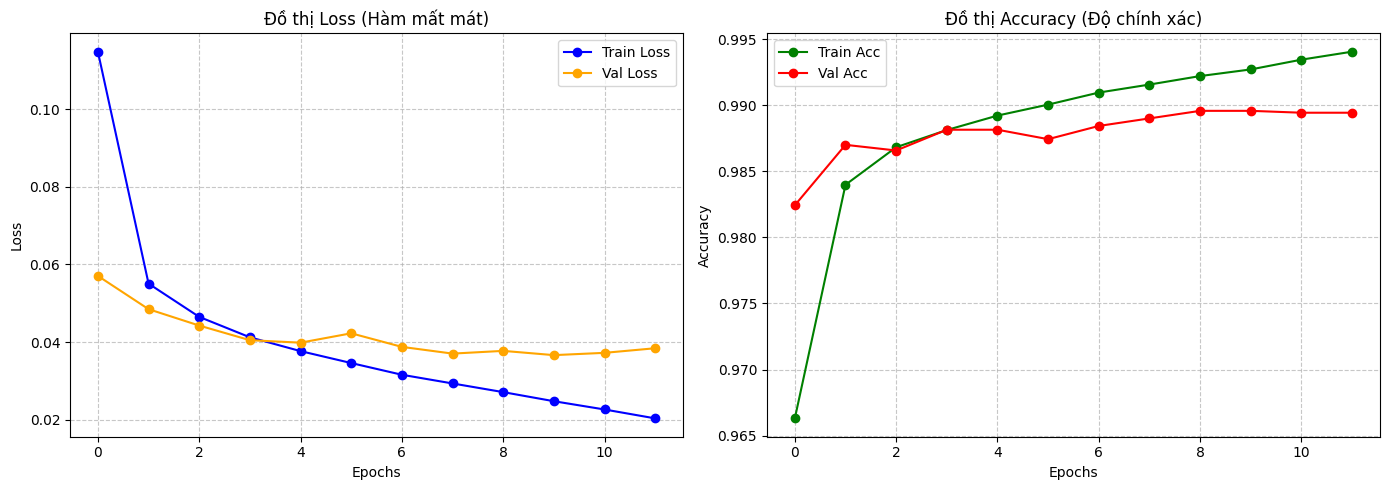


--- LỊCH SỬ HUẤN LUYỆN ---
Epoch 1/20 | Thời gian: 176.2s | Train Loss: 0.1148 | Val Loss: 0.0570 | Val Acc: 0.9824 🌟 [Đã lưu Best Model]
Epoch 2/20 | Thời gian: 178.5s | Train Loss: 0.0551 | Val Loss: 0.0485 | Val Acc: 0.9870 🌟 [Đã lưu Best Model]
Epoch 3/20 | Thời gian: 178.7s | Train Loss: 0.0465 | Val Loss: 0.0443 | Val Acc: 0.9866 🌟 [Đã lưu Best Model]
Epoch 4/20 | Thời gian: 178.7s | Train Loss: 0.0412 | Val Loss: 0.0405 | Val Acc: 0.9881 🌟 [Đã lưu Best Model]
Epoch 5/20 | Thời gian: 178.8s | Train Loss: 0.0377 | Val Loss: 0.0398 | Val Acc: 0.9881 🌟 [Đã lưu Best Model]
Epoch 6/20 | Thời gian: 178.7s | Train Loss: 0.0346 | Val Loss: 0.0423 | Val Acc: 0.9874 ⚠️ [Cảnh báo: Val Loss không giảm 1/2]
Epoch 7/20 | Thời gian: 178.8s | Train Loss: 0.0316 | Val Loss: 0.0388 | Val Acc: 0.9884 🌟 [Đã lưu Best Model]
Epoch 8/20 | Thời gian: 178.7s | Train Loss: 0.0293 | Val Loss: 0.0370 | Val Acc: 0.9890 🌟 [Đã lưu Best Model]
Epoch 9/20 | Thời gian: 178.7s | Train Loss: 0.0271 | Val Loss: 0.0

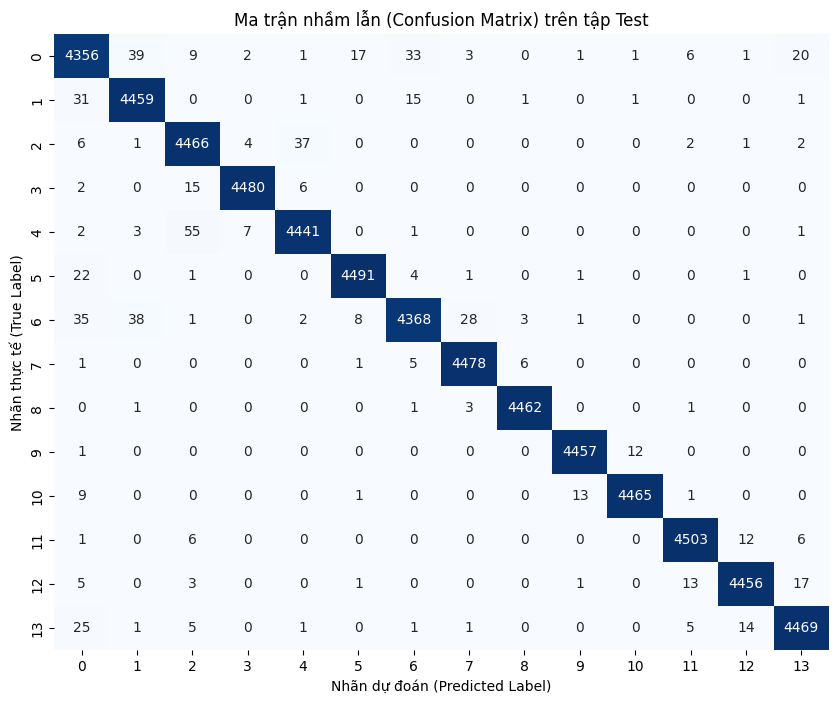

In [7]:
import time
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import clear_output

def calculate_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item()

criterion = nn.CrossEntropyLoss() # Added this line to define criterion
print("7. Bắt đầu quá trình huấn luyện với Live Plotting & Early Stopping...")

# Các biến theo dõi
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
log_history = [] # <--- Danh sách lưu trữ toàn bộ lịch sử dòng log
best_val_loss = float('inf')
model_save_path = "best_rnn_model.pth"
patience = 2
epochs_no_improve = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    start_time = time.time()

    # ==========================
    # 1. QUÁ TRÌNH TRAINING
    # ==========================
    model.train()
    train_loss, train_acc = 0.0, 0.0
    for token_ids, attn_mask, labels in train_loader:
        token_ids, attn_mask, labels = token_ids.to(device), attn_mask.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(token_ids, attn_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)
        train_acc += calculate_accuracy(logits, labels) * len(labels)

    train_loss /= len(processed_datasets["train"])
    train_acc /= len(processed_datasets["train"])

    # ==========================
    # 2. QUÁ TRÌNH VALIDATION
    # ==========================
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for token_ids, attn_mask, labels in val_loader:
            token_ids, attn_mask, labels = token_ids.to(device), attn_mask.to(device), labels.to(device)
            logits = model(token_ids, attn_mask)
            loss = criterion(logits, labels)

            val_loss += loss.item() * len(labels)
            val_acc += calculate_accuracy(logits, labels) * len(labels)

    val_loss /= len(processed_datasets["val"])
    val_acc /= len(processed_datasets["val"])

    # ==========================
    # 3. CẬP NHẬT LỊCH SỬ & LOG
    # ==========================
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    elapsed = time.time() - start_time

    # Tạo câu log cho epoch hiện tại và đưa vào danh sách
    current_log = f"Epoch {epoch}/{CONFIG['epochs']} | Thời gian: {elapsed:.1f}s | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"

    # Kiểm tra Early Stopping & Lưu Model để nối thêm vào log nếu có
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        current_log += f" 🌟 [Đã lưu Best Model]"
    else:
        epochs_no_improve += 1
        current_log += f" ⚠️ [Cảnh báo: Val Loss không giảm {epochs_no_improve}/{patience}]"

    log_history.append(current_log)

    # ==========================
    # 4. VẼ BIỂU ĐỒ REALTIME (LIVE PLOT)
    # ==========================
    clear_output(wait=True) # Xóa khung hình cũ

    plt.figure(figsize=(14, 5))

    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', marker='o', color='blue')
    plt.plot(history['val_loss'], label='Val Loss', marker='o', color='orange')
    plt.title('Đồ thị Loss (Hàm mất mát)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', marker='o', color='green')
    plt.plot(history['val_acc'], label='Val Acc', marker='o', color='red')
    plt.title('Đồ thị Accuracy (Độ chính xác)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show() # Vẽ biểu đồ mới

    # In lại toàn bộ lịch sử log nằm ngay dưới biểu đồ
    print("\n--- LỊCH SỬ HUẤN LUYỆN ---")
    for log_msg in log_history:
        print(log_msg)

    # Kích hoạt chốt chặn dừng sớm
    if epochs_no_improve >= patience:
        print("\n🛑 KÍCH HOẠT EARLY STOPPING: Dừng huấn luyện sớm để chống Overfitting!")
        break

# ==========================================
# 5. ĐÁNH GIÁ TẬP TEST VÀ PHÂN TÍCH LỖI
# ==========================================
print("\n" + "="*50)
print("Đang tải lại trọng số mô hình tốt nhất để kiểm thử trên tập Test...")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for token_ids, attn_mask, labels in test_loader:
        token_ids, attn_mask = token_ids.to(device), attn_mask.to(device)
        logits = model(token_ids, attn_mask)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# In Báo cáo phân loại chi tiết
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT):")
print(classification_report(all_labels, all_preds, digits=4))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
print("\nĐang vẽ Ma trận nhầm lẫn (Confusion Matrix)...")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Test')
plt.ylabel('Nhãn thực tế (True Label)')
plt.xlabel('Nhãn dự đoán (Predicted Label)')
plt.show()

In [ ]:
# Cài đặt thư viện LIME (chạy 1 lần)
!pip install lime

import torch
import torch.nn.functional as F
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

print("8. Bắt đầu Giải thích Mô hình bằng LIME...")

# 1. Khởi tạo công cụ giải thích của LIME
# Khai báo 14 class names của DBpedia (chỉnh lại theo đúng thứ tự nhãn của bạn nếu cần)
class_names = [
    'Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder',
    'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal',
    'Plant', 'Album', 'Film', 'WrittenWork'
]
explainer = LimeTextExplainer(class_names=class_names)

# 2. Hàm Wrapper: Chuyển đổi text thô thành xác suất (Probabilities)
# LIME yêu cầu một hàm nhận vào danh sách chuỗi (list of strings) và trả về mảng numpy (numpy array) các xác suất.
def predictor_wrapper(texts):
    # Tokenize các câu văn do LIME sinh ra
    # LIME sẽ gửi các đoạn văn bản (text) thô, không phải token_ids, nên cần tokenize lại ở đây.
    # Chú ý: Ở đây bạn cần chuyển đổi `texts` (là một danh sách các chuỗi) thành định dạng mà tokenizer của bạn hiểu.
    # Nếu `tokenizer` của bạn là `get_tokenizer("basic_english")` thì nó nhận một chuỗi và trả về list of tokens.
    # Đoạn code dưới đây giả định `tokenizer` có thể xử lý một list các chuỗi và trả về dict với 'input_ids' và 'attention_mask'
    # Nếu không, bạn cần lặp qua từng chuỗi trong `texts`.

    # Dựa trên cách `tokenizer` được định nghĩa trước đó (get_tokenizer("basic_english")),
    # nó không có `return_tensors`, `padding`, `truncation`, `max_length`.
    # Cần điều chỉnh `predictor_wrapper` để phù hợp với `tokenizer` của torchtext.
    processed_token_ids_list = []
    for text_item in texts:
        tokens = tokenizer(text_item)
        token_ids = vocab(tokens)
        if len(token_ids) > CONFIG["max_len"]:
            token_ids = token_ids[:CONFIG["max_len"]]
        else:
            pad_len = CONFIG["max_len"] - len(token_ids)
            token_ids = token_ids + [pad_idx] * pad_len
        processed_token_ids_list.append(token_ids)

    # Tạo tensor và attention mask
    input_ids = torch.tensor(processed_token_ids_list).to(device)
    # Attention mask cho LIME cũng phải được tạo dựa trên token_ids, không phải từ tokenizer trực tiếp
    attention_mask = (input_ids != pad_idx).float().to(device)

    # Đưa qua mô hình
    model.eval()
    with torch.no_grad():
        # Mô hình của bạn nhận `token_ids` và `attention_mask`
        logits = model(input_ids, attention_mask)
        # Dùng Softmax để ép Logits về khoảng 0-1 (Xác suất)
        probs = F.softmax(logits, dim=1)

    return probs.cpu().numpy()

# 3. Chọn một mẫu dữ liệu ngẫu nhiên từ tập Test để "mổ xẻ"
sample_idx = 42 # Bạn có thể đổi số này để xem các câu khác
sample_text = processed_datasets["test"][sample_idx]["clean_text"] # Sửa từ 'text' thành 'clean_text'
true_label = processed_datasets["test"][sample_idx]["label"]

print(f"\n[Văn bản gốc]: {sample_text[:150]}...")
print(f"[Nhãn Thực Tế]: {class_names[true_label]} (ID: {true_label})")

# 4. Chạy LIME để giải thích
# num_features=6: Chỉ lấy 6 từ có ảnh hưởng lớn nhất
# num_samples=500: LIME sẽ thử tạo 500 câu bị xóa từ ngẫu nhiên để test
exp = explainer.explain_instance(
    sample_text,
    predictor_wrapper,
    num_features=6,
    num_samples=500,
    top_labels=1
)

# 5. Hiển thị kết quả
# Trích xuất nhãn mà mô hình tự tin nhất
predicted_label_idx = exp.available_labels()[0]
print(f"[Mô hình Dự Đoán]: {class_names[predicted_label_idx]} (ID: {predicted_label_idx})")

# Vẽ biểu đồ các từ quyết định (Feature Importance)
fig = exp.as_pyplot_figure(label=predicted_label_idx)
plt.title(f"Giải thích của LIME cho dự đoán: {class_names[predicted_label_idx]}")
plt.tight_layout()
plt.show()

# (Tùy chọn trên Colab/Jupyter) Hiển thị giao diện HTML tô màu text cực đẹp
exp.show_in_notebook(text=True)